<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
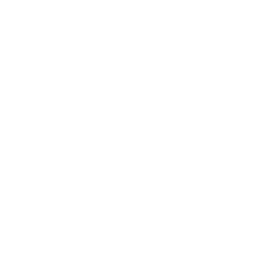
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analisi della Tendenza EWMA del Tasso di Errore Farmacologico</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Sanità / Sicurezza del Paziente &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi Esecutiva

Questa analisi monitora il tasso settimanale di errore farmacologico in un'unità di terapia intensiva (UTI) ospedaliera utilizzando un **grafico di controllo a media mobile ponderata esponenzialmente (EWMA)** di PROC MACONTROL. L'UTI ha introdotto un nuovo sistema elettronico di registrazione della somministrazione dei farmaci (eMAR) nella settimana 51 della finestra di osservazione. I team per la sicurezza del paziente hanno bisogno di un metodo di allerta precoce che segnali rapidamente un aumento sostenuto degli errori, prima che si accumuli un trimestre di segnalazioni di danno.

Il grafico EWMA con peso di smorzamento **lambda = 0,3** viene costruito in due fasi. I limiti di controllo sono innanzitutto stabiliti a partire dalla baseline stabile pre-migrazione (settimane 1-50), poi l'intera serie di 100 settimane viene monitorata rispetto a quei limiti fissi. Il grafico rimane sotto controllo per tutta la baseline e segnala una condizione fuori controllo **fin dalla prima settimana dopo l'avvio**, confermando che la transizione all'eMAR ha coinciso con uno spostamento reale e sostenuto del tasso di errore, e non con il normale rumore settimana-su-settimana.

## Fonti dei Dati

| Fonte | Descrizione | Record |
|--------|-------------|---------|
| WORK.ICU_ERRORS | Tasso settimanale di errore farmacologico per 1.000 somministrazioni per un'UTI, 100 settimane consecutive | 100 |

Una singola UTI viene monitorata settimanalmente. Ogni record riporta il numero della settimana, il tasso di errore per 1.000 somministrazioni, il volume di somministrazioni e il conteggio di errori derivato. Un cambiamento di processo documentato (avvio dell'eMAR) avviene alla settimana 51, spostando verso l'alto la media sottostante del tasso di errore di circa 1,6 per 1.000.

---

In [1]:
/* --------------------------------------------------------
   Genera i dati settimanali di errore farmacologico in UTI
   100 settimane consecutive per un'UTI.
   Un nuovo sistema eMAR viene avviato alla settimana 51, portando
   la media sottostante del tasso di errore da ~3,5 a ~5,1 per 1.000.
   -------------------------------------------------------- */
DATI work.icu_errors;
    CHIAMARE streaminit(42);
    LUNGHEZZA unit_name $12 phase $12;
    unit_name = 'TI';
    base_rate  = 3.5;   /* tasso medio pre-migrazione / 1.000 */
    unit_sigma = 0.45;  /* rumore comune settimana-su-settimana */
    FARE week_num = 1 FINO_A 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        SE_COND administrations < 300 ALLORA administrations = 300;
        /* la migrazione eMAR sposta la media verso l'alto dopo la settimana 50 */
        SE_COND week_num > 50 ALLORA FARE;
            phase = 'POST-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        FINE;
        ALTRIMENTI FARE;
            phase = 'PRE-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        FINE;
        SE_COND error_rate_per_1k < 0 ALLORA error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        USCITA;
    FINE;
    RIMUOVERE base_rate unit_sigma;
    FORMATO week_start_date date9.;
ESEGUIRE;


NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                     Tasso di Errore in UTI: Baseline vs Post-eMAR                                      

                                                  The MEANS Procedure

                            Analysis Variable : error_rate_per_1k Tasso di Errore per 1.000

        Fase               N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        POST-eMAR             50           5.11           0.44           3.69           5.96
        PRE-eMAR              50           3.50           0.48           2.55           4.71
        ------------------------------------------------------------------------------------

                                    Analysis Variable : error_count Conteggio Errori

        Fase               N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


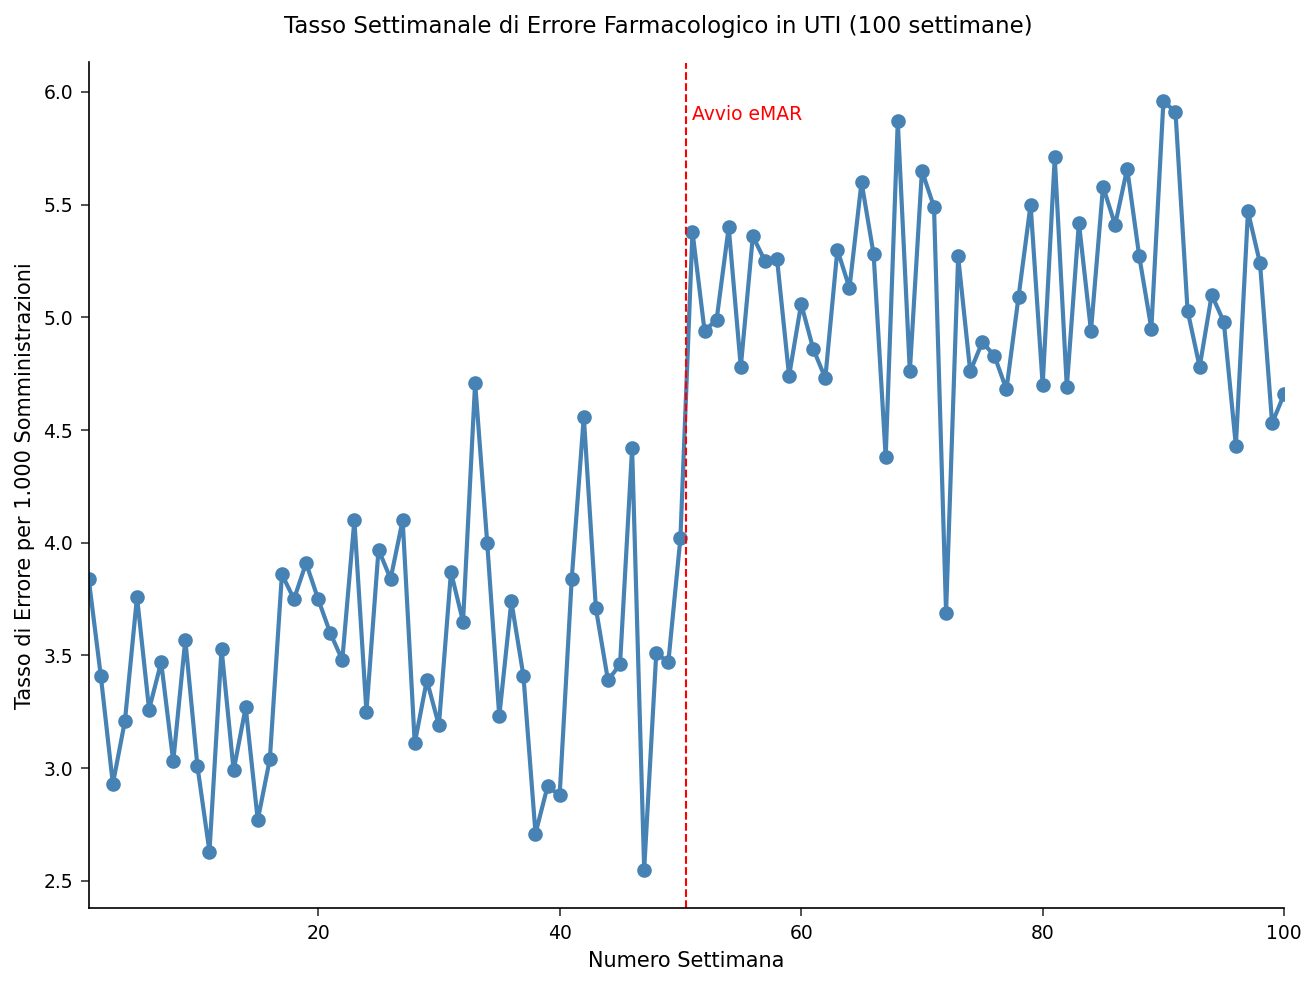

In [2]:
/* --------------------------------------------------------
   Confronta il tasso di errore prima e dopo l'avvio dell'eMAR,
   e traccia l'andamento settimanale.
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.icu_errors n mean std MIN MAX maxdec=2;
    CLASSE phase;
    VARIABILE error_rate_per_1k error_count administrations;
    ETICHETTA phase="Fase" error_rate_per_1k="Tasso di Errore per 1.000" error_count="Conteggio Errori" administrations="Somministrazioni";
    TITOLO "Tasso di Errore in UTI: Baseline vs Post-eMAR";
ESEGUIRE;

PROCEDURA SGPLOT DATI=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   LABEL="Avvio eMAR";
    XAXIS LABEL="Numero Settimana";
    YAXIS LABEL="Tasso di Errore per 1.000 Somministrazioni";
    TITOLO "Tasso Settimanale di Errore Farmacologico in UTI (100 settimane)";
ESEGUIRE;

---

In [3]:
/* --------------------------------------------------------
   Fase I: stabilisce i limiti di controllo EWMA a partire dalla
   baseline stabile pre-migrazione (settimane 1-50). Questi limiti
   fissi diventano il metro di paragone per l'intero periodo di
   monitoraggio.
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.icu_errors(DOVE=(week_num <= 50)) NOPRINT;
    VARIABILE error_rate_per_1k;
    USCITA out=work.baseline_stats mean=base_mean std=base_std;
ESEGUIRE;

DATI work.icu_limits;
    IMPOSTARE work.baseline_stats;
    LUNGHEZZA _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* linea centrale della baseline */
    _STDDEV_ = base_std;    /* sigma di causa comune della baseline */
    _LIMITN_ = 1;
    MANTENERE _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.icu_limits noobs;
    TITOLO "Fase I: Input dei Limiti di Controllo (settimane baseline 1-50)";
ESEGUIRE;

                            Fase I: Input dei Limiti di Controllo (settimane baseline 1-50)                             

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                            Fase I: Input dei Limiti di Controllo (settimane baseline 1-50)                             


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/a9b93d8e-d87e-4210-af1a-f59ba14fb294/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


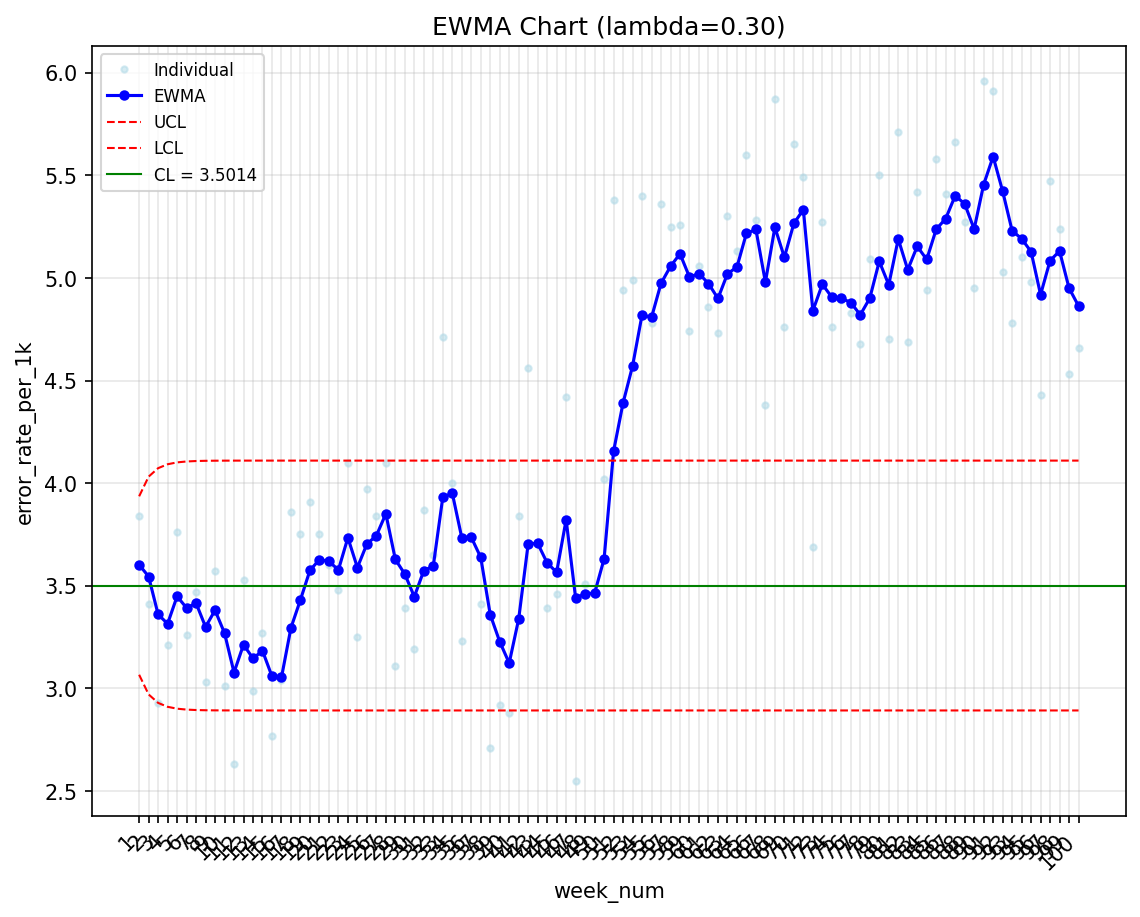

In [4]:
/* --------------------------------------------------------
   Fase II: monitora l'intera serie di 100 settimane rispetto ai
   limiti fissi della baseline. lambda=0,3 offre un rilevamento
   reattivo, appropriato per la sorveglianza della sicurezza del
   paziente.
   -------------------------------------------------------- */
PROCEDURA macontrol DATI=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        weight    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    ETICHETTA error_rate_per_1k =
          "Errori Farmacologici per 1.000 Somministrazioni";
    TITOLO "Grafico EWMA: Tasso di Errore Farmacologico in UTI (lambda=0,3)";
ESEGUIRE;

---

In [5]:
/* --------------------------------------------------------
   Identifica ogni settimana in cui l'EWMA supera i limiti della
   baseline e riporta quando il grafico segnala per la prima volta.
   -------------------------------------------------------- */
DATI work.signals;
    IMPOSTARE work.icu_table;
    DOVE _EXLIM_ ne ' ' E_LOG _EXLIM_ ne '0';
ESEGUIRE;

proc sql;
    select count(*)        as n_signals          label='Settimane di Segnale',
           min(week_num)    as first_signal_week  label='Prima Settimana di Segnale',
           max(_EWMA_)      as peak_ewma format=6.3 label='EWMA di Picco'
    from work.signals;
quit;

PROCEDURA STAMPARE DATI=work.signals(obs=8);
    VARIABILE week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    TITOLO "Primi Segnali EWMA Fuori Controllo";
ESEGUIRE;

                            Fase I: Input dei Limiti di Controllo (settimane baseline 1-50)                             

Settimane di Segnale  Prima Settimana di Segnale  EWMA di Picco
--------------------  --------------------------  -------------
                  50                        51.0          5.591
                                           Primi Segnali EWMA Fuori Controllo                                           

  Obs  week_num    _EWMA_   _UCLE_  _EXLIM_
    1        51  4.155551  4.10998        1
    2        52  4.390886  4.10998        1
    3        53   4.57062  4.10998        1
    4        54  4.819434  4.10998        1
    5        55  4.807604  4.10998        1
    6        56  4.973323  4.10998        1
    7        57  5.056326  4.10998        1
    8        58  5.117428  4.10998        1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Interpretazione

L'analisi EWMA a due fasi separa in modo netto la normale variazione settimana-su-settimana dal reale cambiamento di processo avvenuto all'avvio dell'eMAR.

**Baseline (settimane 1-50).** PROC MEANS riporta un tasso di errore medio in baseline di **3,50 per 1.000 somministrazioni** (deviazione standard 0,48), contro una media post-migrazione di **5,11** (deviazione standard 0,44) -- uno spostamento sostenuto verso l'alto di circa **1,6 errori per 1.000**. Il volume di somministrazioni è comparabile tra le due fasi (795 contro 790 a settimana), quindi il cambiamento riflette il *tasso* di errore, non un'oscillazione del carico di lavoro.

**Limiti di controllo.** I limiti sono fissati solo a partire dalla baseline: linea centrale **3,5014**, sigma di baseline **0,4829**. Con peso di smorzamento lambda = 0,3 e limiti a 3 sigma, il limite superiore EWMA si assesta al suo valore asintotico di circa **4,11**. Per tutte le settimane 1-50 la statistica EWMA resta entro questi limiti -- la baseline produce **zero falsi allarmi**, confermando che il grafico non è ipersensibile.

**Rilevamento.** Il grafico segnala una condizione fuori controllo fin dalla **prima settimana dopo l'avvio (settimana 51)**, dove l'EWMA raggiunge **4,156**, appena sopra il limite di 4,11. Da quel punto la statistica sale costantemente e resta sopra il limite superiore per l'intero periodo post-migrazione: **tutte le 50 settimane post-migrazione (51-100) segnalano**, e l'EWMA raggiunge il picco di **5,591** intorno alla settimana 91. La reattività di lambda = 0,3 fa sì che il peggioramento venga segnalato immediatamente, anziché dopo diverse settimane di accumulo.

**Azione.** Una violazione EWMA sostenuta che inizia nella settimana di un avvio eMAR è una forte evidenza che il nuovo sistema -- e non il caso -- ha determinato l'aumento. Il comitato per la sicurezza del paziente dovrebbe considerare la settimana 51 come il punto di cambiamento, verificare i flussi di lavoro di ordinazione dei farmaci e di override dell'eMAR introdotti quella settimana, e mantenere il grafico attivo rispetto ai limiti di baseline originali finché l'EWMA non ritorna sotto 4,11. I file esportati `icu_ewma_signals.csv` (50 settimane di segnale) e `icu_ewma_table.csv` forniscono la traccia di evidenza SPC documentata per la revisione di prontezza continua della Joint Commission.

---

In [6]:
/* --------------------------------------------------------
   Esporta la tabella EWMA e l'elenco dei segnali per la
   documentazione di prontezza continua della Joint Commission.
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
ESEGUIRE;

PROCEDURA EXPORT DATI=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
ESEGUIRE;


NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>